# «Питомцы ВКонтакте»: оценка аудитории и выручки до 2027 года

Мини-приложение [vk.com/pets](https://vk.com/pets) работает с 2021 года как онлайн-паспорт питомца. В этом ноутбуке я считаю, сколько пользователей и денег оно может получить, если превратить его из анкеты в ежедневный инструмент ухода и связать с VK Календарём, Почтой, Облаком и Заметками.

**Что внутри**

1. Исходные данные о рынке из открытых источников
2. Опрос владельцев питомцев: разбор ответов
3. TAM / SAM / SOM и прогноз MAU и DAU
4. Модель выручки по шести источникам в трёх сценариях
5. Анализ чувствительности (торнадо-диаграмма)
6. Симуляция Монте-Карло: диапазон выручки 2027 года
7. Выводы

**Стек:** Python, pandas, NumPy, matplotlib.

> **Примечание о данных.** Рыночные показатели (число питомцев, объём рынка, аудитория VK) взяты из открытых источников, ссылки — в разделе 1. Результаты опроса, текущая аудитория приложения, доли сегментов, выручка 2025 года и все прогнозы **смоделированы** на основе этих источников и отраслевых ориентиров. Это учебный кейс, а не данные VK.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.float_format', lambda x: f'{x:,.1f}'.replace(',', ' '))
plt.rcParams.update({
    'figure.figsize': (10, 5), 'figure.dpi': 110, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titleweight': 'bold', 'axes.titlesize': 13, 'font.size': 11,
})
BLUE, LIGHT_BLUE, ORANGE, GREY = '#0066E0', '#8FB9FF', '#FF8A3D', '#6B7686'
YEARS = [2025, 2026, 2027]
RNG = np.random.default_rng(42)

## 1. Исходные данные о рынке

Все цифры ниже опубликованы. Там, где источник даёт только оценку, это указано в названии показателя.

In [ ]:
market = pd.DataFrame([
    ('Кошек в России, млн',                     49.2,  'Перепись питомцев 2023 (ЦИПБЖ, Ipsos)'),
    ('Собак в России, млн',                     25.5,  'Перепись питомцев 2023 (ЦИПБЖ, Ipsos)'),
    ('Доля семей с питомцем, %',                56.0,  'Перепись питомцев 2023 (ЦИПБЖ, Ipsos)'),
    ('Домохозяйств в России, млн',              55.6,  'Всероссийская перепись населения 2020'),
    ('Рынок зоотоваров 2025, млрд ₽',          590.0,  'Коммерсантъ, «Зооинформ»'),
    ('Рост рынка зоотоваров 2025, %',           15.8,  '«Зооинформ»'),
    ('Доля онлайна в зоотоварах, %',            22.0,  '«Зооинформ»'),
    ('Ветуслуги 2024, млрд ₽ (оценка)',         50.0,  'Рамблер/Финансы'),
    ('Ветпрепараты в рознице 2025, млрд ₽',     49.1,  'RNC Pharma'),
    ('MAU ВКонтакте, II кв. 2026, млн',         94.3,  'VK, пресс-релиз от 13.08.2026'),
    ('DAU ВКонтакте, II кв. 2026, млн',         65.2,  'VK, пресс-релиз от 13.08.2026'),
], columns=['Показатель', 'Значение', 'Источник'])
market

,Показатель,Значение,Источник
0,"Кошек в России, млн",49.2,"Перепись питомцев 2023 (ЦИПБЖ, Ipsos)"
1,"Собак в России, млн",25.5,"Перепись питомцев 2023 (ЦИПБЖ, Ipsos)"
2,"Доля семей с питомцем, %",56.0,"Перепись питомцев 2023 (ЦИПБЖ, Ipsos)"
3,"Домохозяйств в России, млн",55.6,Всероссийская перепись населения 2020
4,"Рынок зоотоваров 2025, млрд ₽",590.0,"Коммерсантъ, «Зооинформ»"
5,"Рост рынка зоотоваров 2025, %",15.8,«Зооинформ»
6,"Доля онлайна в зоотоварах, %",22.0,«Зооинформ»
7,"Ветуслуги 2024, млрд ₽ (оценка)",50.0,Рамблер/Финансы
8,"Ветпрепараты в рознице 2025, млрд ₽",49.1,RNC Pharma
9,"MAU ВКонтакте, II кв. 2026, млн",94.3,"VK, пресс-релиз от 13.08.2026"


Продлим рынок до 2027 года. Для зоотоваров беру середину отраслевого прогноза на 2026 год (+10–13%) и чуть более медленный 2027-й, для ветуслуг — похожую траекторию.

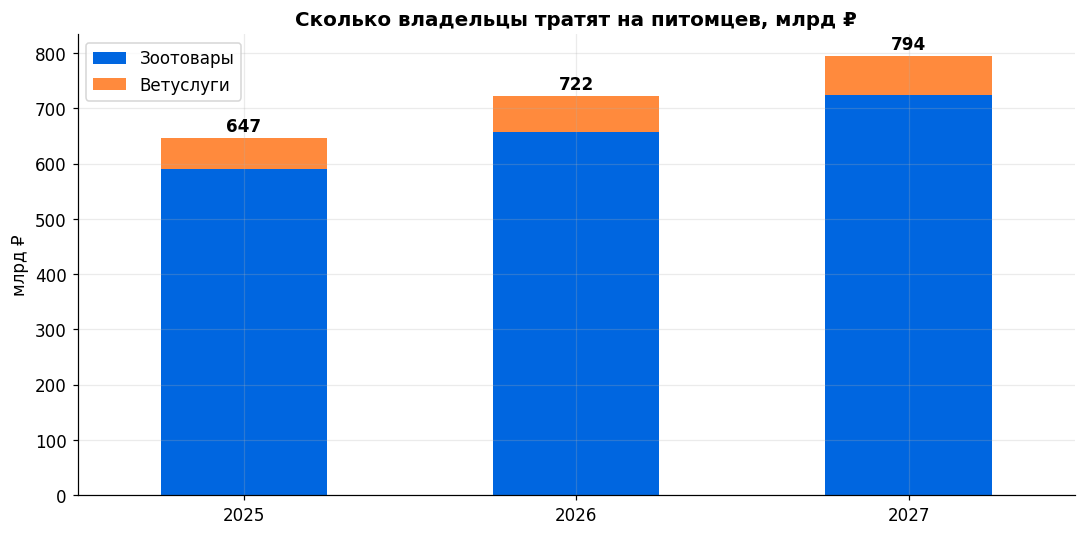

,Зоотовары,Ветуслуги,Итого
2025,590.0,57.0,647.0
2026,657.8,63.8,721.7
2027,723.6,70.2,793.9


In [ ]:
growth = pd.DataFrame({
    'Зоотовары':  {2025: 590.0, 2026: 590.0 * 1.115, 2027: 590.0 * 1.115 * 1.10},
    'Ветуслуги':  {2025: 50.0 * 1.14, 2026: 50.0 * 1.14 * 1.12, 2027: 50.0 * 1.14 * 1.12 * 1.10},
})
growth['Итого'] = growth.sum(axis=1)

ax = growth[['Зоотовары', 'Ветуслуги']].plot(kind='bar', stacked=True, color=[BLUE, ORANGE], rot=0)
for i, total in enumerate(growth['Итого']):
    ax.text(i, total + 12, f'{total:.0f}', ha='center', fontweight='bold')
ax.set_title('Сколько владельцы тратят на питомцев, млрд ₽')
ax.set_ylabel('млрд ₽'); ax.set_xlabel('')
plt.tight_layout(); plt.show()
growth.round(1)

## 2. Опрос владельцев питомцев (смоделированные данные)

Чтобы проверить гипотезы о проблемах владельцев, нужен опрос. Здесь он смоделирован: 318 респондентов из тематических сообществ ВКонтакте, распределения ответов заданы по открытым исследованиям. Датасет собирается на уровне отдельных респондентов, чтобы его можно было резать по сегментам так же, как настоящие данные.

In [ ]:
N = 318

def exact_share(p, n=N):
    # Бинарный признак с точной долей p, перемешанный случайно.
    k = round(p * n)
    arr = np.array([1] * k + [0] * (n - k))
    RNG.shuffle(arr)
    return arr

survey = pd.DataFrame({
    'pet': RNG.choice(['Кошка', 'Собака', 'Другое'], size=N, p=[0.58, 0.34, 0.08]),
    'gender': RNG.choice(['Ж', 'М'], size=N, p=[0.72, 0.28]),
    'age': np.clip(RNG.normal(34, 9, N).round(), 18, 70).astype(int),
    'forgot_procedure': exact_share(0.71),
    'paper_passport_only': exact_share(0.58),
    'lost_passport': exact_share(0.23),
    'google_symptoms_first': exact_share(0.64),
    'wants_online_booking': exact_share(0.47),
    'family_confusion': exact_share(0.39),
    'heard_of_vk_pets': exact_share(0.12),
})
survey.head()

,pet,gender,age,forgot_procedure,paper_passport_only,lost_passport,google_symptoms_first,wants_online_booking,family_confusion,heard_of_vk_pets
0,Собака,Ж,36,1,0,1,0,0,0,0
1,Кошка,М,21,0,0,0,0,0,1,0
2,Собака,М,38,0,1,1,0,0,0,0
3,Собака,Ж,27,0,1,0,0,0,1,0
4,Кошка,Ж,22,1,1,0,1,0,1,0


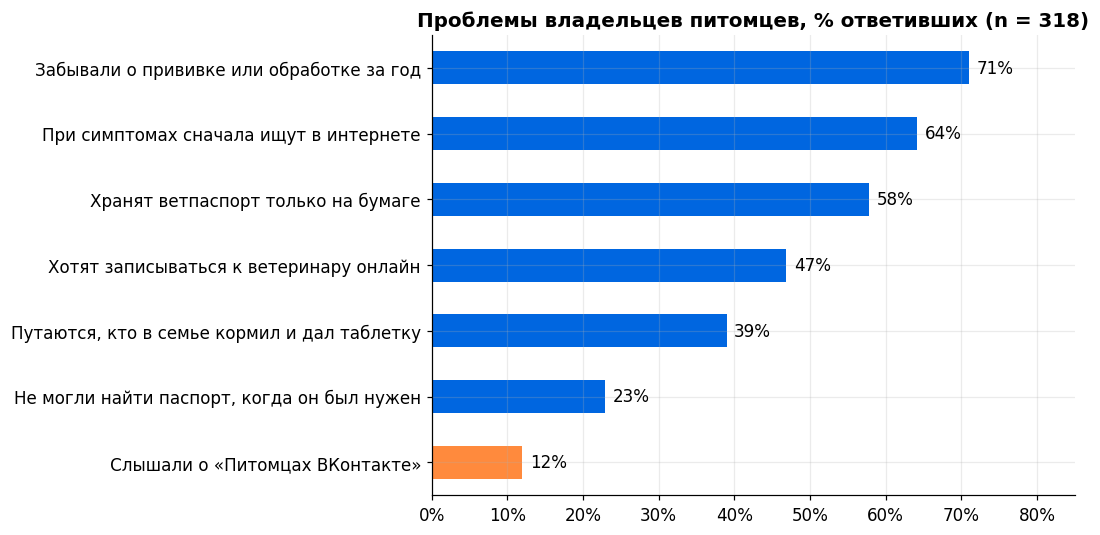

Медианный возраст, лет: 34; женщин: 69%


In [ ]:
labels = {
    'forgot_procedure': 'Забывали о прививке или обработке за год',
    'google_symptoms_first': 'При симптомах сначала ищут в интернете',
    'paper_passport_only': 'Хранят ветпаспорт только на бумаге',
    'wants_online_booking': 'Хотят записываться к ветеринару онлайн',
    'family_confusion': 'Путаются, кто в семье кормил и дал таблетку',
    'lost_passport': 'Не могли найти паспорт, когда он был нужен',
    'heard_of_vk_pets': 'Слышали о «Питомцах ВКонтакте»',
}
shares = (survey[list(labels)].mean() * 100).rename(labels).sort_values()

ax = shares.plot(kind='barh', color=[ORANGE if 'Питомцах' in i else BLUE for i in shares.index])
for i, v in enumerate(shares):
    ax.text(v + 1, i, f'{v:.0f}%', va='center')
ax.set_title(f'Проблемы владельцев питомцев, % ответивших (n = {N})')
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_xlim(0, 85)
plt.tight_layout(); plt.show()
print(f"Медианный возраст, лет: {survey['age'].median():.0f}; женщин: {(survey['gender'] == 'Ж').mean():.0%}")

Проверим, отличаются ли кошатники и собачники. Если различий нет, продукту не нужны разные сценарии онбординга для этих групп.

In [ ]:
by_pet = (survey.groupby('pet')[list(labels)].mean() * 100).rename(columns=labels).T.round(0)
by_pet[['Кошка', 'Собака', 'Другое']]

pet,Кошка,Собака,Другое
Забывали о прививке или обработке за год,72.0,74.0,55.0
При симптомах сначала ищут в интернете,65.0,66.0,50.0
Хранят ветпаспорт только на бумаге,56.0,59.0,68.0
Хотят записываться к ветеринару онлайн,46.0,45.0,59.0
"Путаются, кто в семье кормил и дал таблетку",38.0,38.0,50.0
"Не могли найти паспорт, когда он был нужен",26.0,17.0,23.0
Слышали о «Питомцах ВКонтакте»,13.0,9.0,18.0


Доли распределены по видам питомцев случайно, поэтому разница между группами здесь — просто шум выборки. В настоящем опросе на этом шаге стоит посчитать хи-квадрат и проверить, значима ли она.

## 3. TAM / SAM / SOM

Считаю в людях, а не в животных: приложением пользуется владелец.

| Уровень | Логика |
|---|---|
| **TAM** | семьи × доля с питомцем × ухаживающих на семью × доля интернет-пользователей |
| **SAM** | TAM × охват ВКонтакте × доля тех, кто регулярно водит питомца к ветеринару |
| **SOM** | прогноз MAU приложения |

In [ ]:
A = dict(
    households=55.6,           # млн, перепись 2020
    share_with_pet=0.56,       # перепись питомцев 2023
    caregivers_per_hh=1.5,     # допущение: взрослые, участвующие в уходе
    internet_share=0.90,       # доля интернет-пользователей
    vk_reach=0.88,             # 94,3 млн MAU VK / ~107 млн интернет-аудитории
    regular_care=0.55,         # допущение: регулярные прививки и визиты к ветеринару
    owners_growth={2025: 1.00, 2026: 1.02, 2027: 1.04},
)

def tam_sam(a=A):
    rows = []
    for y in YEARS:
        tam = a['households'] * a['share_with_pet'] * a['caregivers_per_hh'] * a['internet_share'] * a['owners_growth'][y]
        sam = tam * a['vk_reach'] * a['regular_care']
        rows.append((y, round(tam, 1), round(sam, 1)))
    return pd.DataFrame(rows, columns=['year', 'TAM', 'SAM']).set_index('year')

audience = tam_sam()

MAU = {  # млн, смоделированные сценарии
    'Пессимистичный': {2025: 0.9, 2026: 1.1, 2027: 1.9},
    'Базовый':        {2025: 0.9, 2026: 1.3, 2027: 2.8},
    'Оптимистичный':  {2025: 0.9, 2026: 1.5, 2027: 4.2},
}
DAU_MAU = {2025: 0.10, 2026: 0.12, 2027: 0.17}

audience['SOM (MAU, база)'] = pd.Series(MAU['Базовый'])
audience['Доля SOM в SAM, %'] = (audience['SOM (MAU, база)'] / audience['SAM'] * 100).round(1)
audience['DAU, тыс.'] = (audience['SOM (MAU, база)'] * pd.Series(DAU_MAU) * 1000).round(0)
audience

,TAM,SAM,"SOM (MAU, база)","Доля SOM в SAM, %","DAU, тыс."
year,,,,,
2025,42.0,20.3,0.9,4.4,90.0
2026,42.9,20.8,1.3,6.2,156.0
2027,43.7,21.2,2.8,13.2,476.0


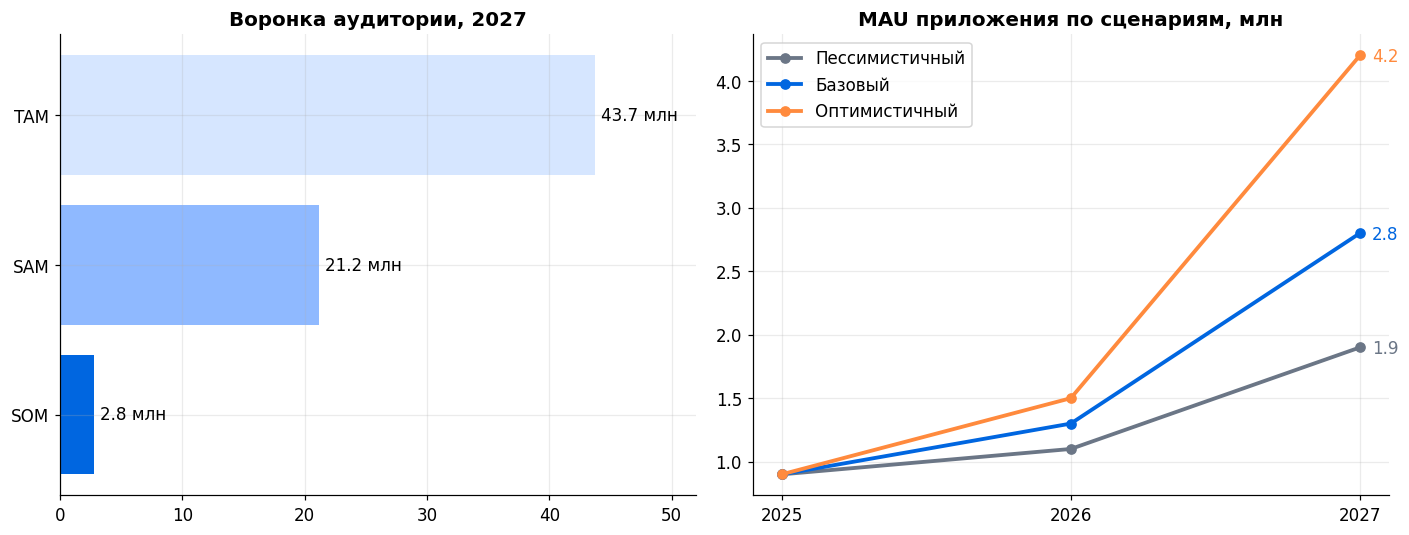

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

vals = audience.loc[2027, ['TAM', 'SAM', 'SOM (MAU, база)']]
ax1.barh(['SOM', 'SAM', 'TAM'], vals[::-1], color=[BLUE, LIGHT_BLUE, '#D6E6FF'])
for i, v in enumerate(vals[::-1]):
    ax1.text(v + 0.5, i, f'{v:.1f} млн', va='center')
ax1.set_title('Воронка аудитории, 2027'); ax1.set_xlim(0, 52)

for (name, s), c in zip(MAU.items(), [GREY, BLUE, ORANGE]):
    ax2.plot(YEARS, list(s.values()), marker='o', lw=2.5, color=c, label=name)
    ax2.annotate(f'{s[2027]}', (2027, s[2027]), textcoords='offset points', xytext=(8, -4), color=c)
ax2.set_title('MAU приложения по сценариям, млн'); ax2.set_xticks(YEARS); ax2.legend()
plt.tight_layout(); plt.show()

**Почему 2,8 млн MAU в 2027 году в базовом сценарии.** Это 3% месячной аудитории ВКонтакте и 13% SAM. Рост опирается на точки входа внутри ВК: блок «Мои питомцы» в профиле и подсказку «Завести паспорт» при публикации фото с животным. Их видят десятки миллионов человек, поэтому даже доля процента конверсии даёт сотни тысяч новых пользователей в месяц.

## 4. Модель выручки

Шесть источников денег. Новые функции запускаются в IV квартале 2026 года, поэтому в 2026 году работает только четверть годового эффекта (`ramp`).

In [ ]:
P = dict(  # параметры монетизации (допущения)
    sub_conv=0.03, sub_price=149,                         # подписка «Питомцы+», ₽/мес
    vet_share=0.15, vet_visits=1.6, vet_cpa=150,          # запись к ветеринару, CPA ₽
    tele_share=0.04, tele_n=1.5, tele_check=690, tele_take=0.25,
    ecom_share=0.10, ecom_orders=6, ecom_check=1900, ecom_take=0.05,
    ins_share=0.006, ins_premium=5500, ins_take=0.25,
)
RAMP = {2025: 0.0, 2026: 0.25, 2027: 1.0}
ADS = {'Пессимистичный': {2025: 18, 2026: 35, 2027: 110},
       'Базовый':        {2025: 18, 2026: 40, 2027: 150},
       'Оптимистичный':  {2025: 18, 2026: 45, 2027: 200}}

def revenue(mau, ramp, ads, p=P):
    # Выручка в млн ₽ при MAU в млн человек.
    k = ramp
    return {
        'Подписка':       mau * p['sub_conv'] * p['sub_price'] * 12 * k,
        'Запись к врачу': mau * p['vet_share'] * p['vet_visits'] * p['vet_cpa'] * k,
        'Телемедицина':   mau * p['tele_share'] * p['tele_n'] * p['tele_check'] * p['tele_take'] * k,
        'Корм и товары':  mau * p['ecom_share'] * p['ecom_orders'] * p['ecom_check'] * p['ecom_take'] * k,
        'Страхование':    mau * p['ins_share'] * p['ins_premium'] * p['ins_take'] * k,
        'Реклама':        ads,
    }

rev = pd.concat({
    sc: pd.DataFrame({y: revenue(MAU[sc][y], RAMP[y], ADS[sc][y]) for y in YEARS})
    for sc in MAU
})
rev.loc[('Базовый', slice(None)), :]

2025  2026  2027
Базовый Подписка         0.0  17.4 150.2
        Запись к врачу   0.0  11.7 100.8
        Телемедицина     0.0   3.4  29.0
        Корм и товары    0.0  18.5 159.6
        Страхование      0.0   2.7  23.1
        Реклама         18.0  40.0 150.0

In [ ]:
totals = rev.groupby(level=0).sum().loc[list(MAU)]
totals['ARPU 2027, ₽'] = totals[2027] / pd.Series({k: v[2027] for k, v in MAU.items()})
totals.round(1)

,2025,2026,2027,"ARPU 2027, ₽"
Пессимистичный,18.0,80.4,424.0,223.1
Базовый,18.0,93.7,612.7,218.8
Оптимистичный,18.0,107.0,894.0,212.9


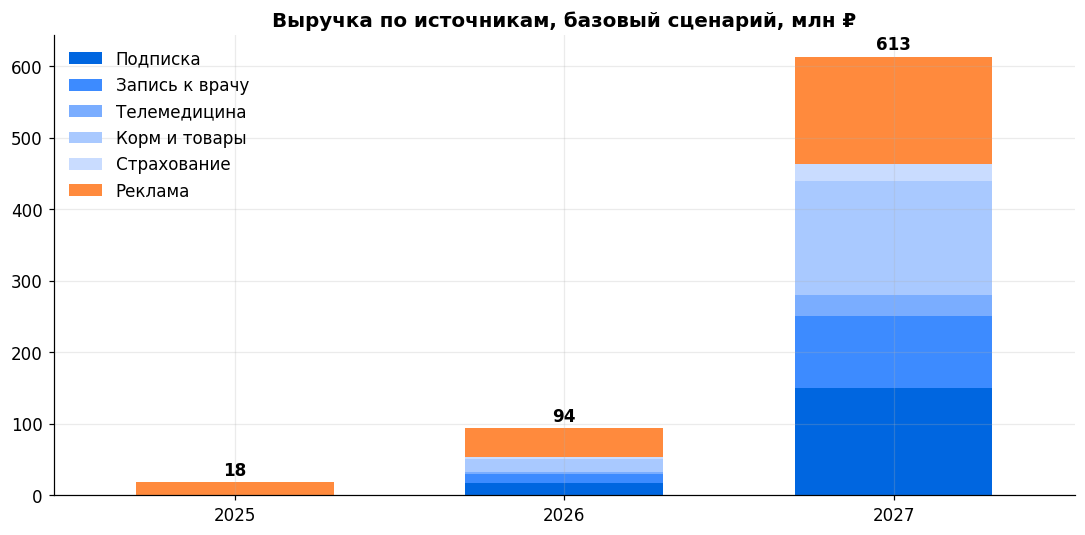

In [ ]:
base = rev.loc['Базовый']
colors = [BLUE, '#3D8BFF', '#7AADFF', '#A9C9FF', '#C9DCFF', ORANGE]
ax = base.T.plot(kind='bar', stacked=True, color=colors, rot=0, width=0.6)
for i, y in enumerate(YEARS):
    ax.text(i, base[y].sum() + 10, f'{base[y].sum():.0f}', ha='center', fontweight='bold')
ax.set_title('Выручка по источникам, базовый сценарий, млн ₽')
ax.legend(loc='upper left', frameon=False); ax.set_xlabel('')
plt.tight_layout(); plt.show()

## 5. Чувствительность

Какие допущения сильнее всего двигают выручку 2027 года? Меняю каждый параметр на ±30%, остальные оставляю на месте.

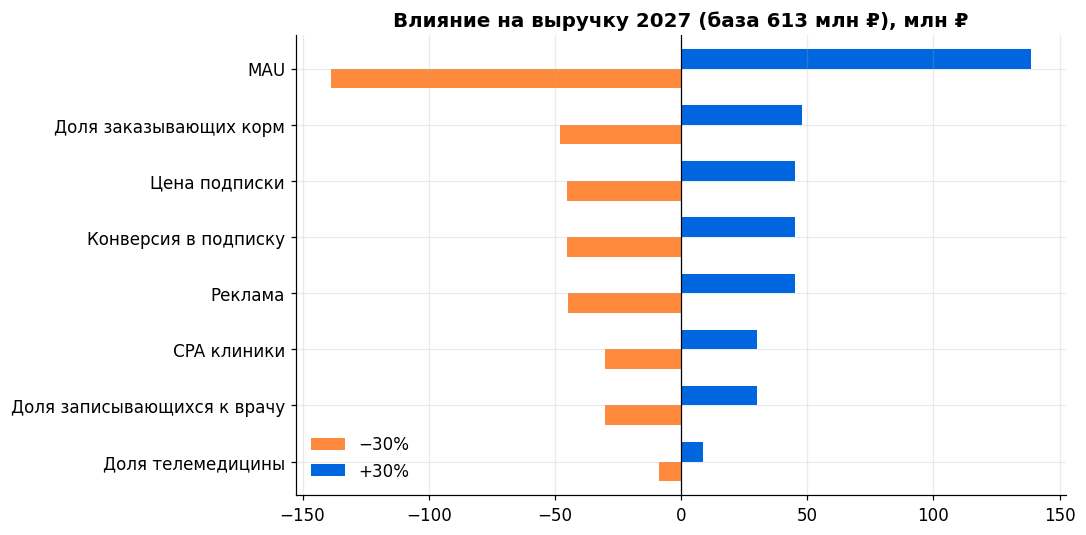

,−30%,+30%
Параметр,,
MAU,-138.8,138.8
Доля заказывающих корм,-47.9,47.9
Цена подписки,-45.1,45.1
Конверсия в подписку,-45.1,45.1
Реклама,-45.0,45.0
CPA клиники,-30.2,30.2
Доля записывающихся к врачу,-30.2,30.2
Доля телемедицины,-8.7,8.7


In [ ]:
BASE_2027 = sum(revenue(MAU['Базовый'][2027], 1.0, ADS['Базовый'][2027]).values())

drivers = {
    'MAU': None, 'Реклама': None,
    'sub_conv': 'Конверсия в подписку', 'sub_price': 'Цена подписки',
    'ecom_share': 'Доля заказывающих корм', 'vet_share': 'Доля записывающихся к врачу',
    'vet_cpa': 'CPA клиники', 'tele_share': 'Доля телемедицины',
}
rows = []
for key, name in drivers.items():
    res = []
    for m in (0.7, 1.3):
        p, mau, ads = dict(P), MAU['Базовый'][2027], ADS['Базовый'][2027]
        if key == 'MAU': mau *= m
        elif key == 'Реклама': ads *= m
        else: p[key] *= m
        res.append(sum(revenue(mau, 1.0, ads, p).values()) - BASE_2027)
    rows.append((name or key, *res))

tornado = pd.DataFrame(rows, columns=['Параметр', '−30%', '+30%']).set_index('Параметр')
tornado = tornado.reindex(tornado['+30%'].abs().sort_values().index)

ax = tornado.plot(kind='barh', color=[ORANGE, BLUE], width=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f'Влияние на выручку 2027 (база {BASE_2027:.0f} млн ₽), млн ₽')
ax.set_ylabel(''); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
tornado.round(1).iloc[::-1]

Сильнее всего выручку двигает MAU, потому что от него зависят все транзакционные источники. Дальше почти вровень идут доля пользователей, заказывающих корм, подписка (её цена и конверсия дают одинаковый эффект) и реклама. Отсюда практический вывод: после роста MAU первыми стоит тестировать механику повторного заказа корма, затем цену и состав подписки.

## 6. Монте-Карло: диапазон выручки 2027 года

Сценарии дают три точки. Чтобы получить распределение, разыгрываю ключевые допущения 10 000 раз: MAU и ключевые конверсии берутся из треугольных распределений, реклама — из равномерного.

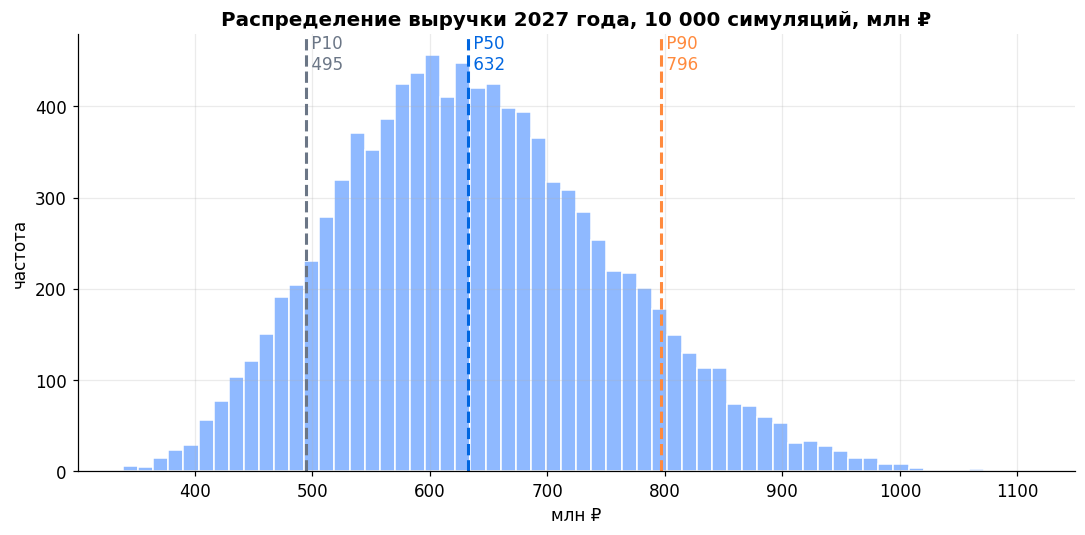

P10 = 495, P50 = 632, P90 = 796 млн ₽; вероятность выручки ниже 424 млн ₽ (пессимистичный сценарий): 2%


In [ ]:
n = 10_000
sim_mau  = RNG.triangular(1.6, 2.8, 4.5, n)
sim_ads  = RNG.uniform(100, 210, n)
sim_sub  = RNG.triangular(0.012, 0.03, 0.045, n)
sim_ecom = RNG.triangular(0.05, 0.10, 0.15, n)
sim_vet  = RNG.triangular(0.08, 0.15, 0.22, n)

sims = np.empty(n)
for i in range(n):
    p = dict(P, sub_conv=sim_sub[i], ecom_share=sim_ecom[i], vet_share=sim_vet[i])
    sims[i] = sum(revenue(sim_mau[i], 1.0, sim_ads[i], p).values())

p10, p50, p90 = np.percentile(sims, [10, 50, 90])
ax = plt.gca()
ax.hist(sims, bins=60, color=LIGHT_BLUE, edgecolor='white')
for v, lab, c in [(p10, 'P10', GREY), (p50, 'P50', BLUE), (p90, 'P90', ORANGE)]:
    ax.axvline(v, color=c, lw=2, ls='--'); ax.text(v, ax.get_ylim()[1] * 0.92, f' {lab}\n {v:.0f}', color=c)
ax.set_title('Распределение выручки 2027 года, 10 000 симуляций, млн ₽')
ax.set_xlabel('млн ₽'); ax.set_ylabel('частота')
plt.tight_layout(); plt.show()
print(f'P10 = {p10:.0f}, P50 = {p50:.0f}, P90 = {p90:.0f} млн ₽; вероятность выручки ниже 424 млн ₽ (пессимистичный сценарий): {(sims < 424).mean():.0%}')

## 7. Выводы

- **Рынок большой и растёт.** Около 75 млн кошек и собак, питомец есть в 56% семей. К 2027 году владельцы будут тратить на товары и ветеринарию порядка 790 млрд ₽ в год.
- **Главная проблема продукта — удержание.** В смоделированном опросе 71% владельцев забывали о процедурах, а о «Питомцах ВКонтакте» слышали только 12%. Приложению нужен повод открывать его каждую неделю: план ухода, семейный доступ, расчёт остатка корма.
- **Аудитория:** TAM — 43,7 млн человек, SAM — 21,2 млн, SOM в базовом сценарии — 2,8 млн MAU и около 480 тыс. DAU в 2027 году.
- **Выручка 2027 года:** 613 млн ₽ в базовом сценарии. По Монте-Карло центральный диапазон P10–P90 — примерно 495–796 млн ₽, это уже, чем разброс сценариев (424–894 млн ₽): сценарии сдвигают все допущения в одну сторону сразу, а в симуляции они компенсируют друг друга. Выручка ниже пессимистичного сценария выпадает примерно в 2% случаев.
- **Что проверять первым:** MAU (точки входа внутри ВК), конверсию в подписку и долю пользователей, которые заказывают корм через приложение.

---

*Рыночные данные взяты из открытых источников, опрос и прогнозы смоделированы. Источники: перепись домашних питомцев 2023 (ЦИПБЖ, Ipsos); «Ромир», 2025; VK, результаты за II квартал 2026 года; Коммерсантъ; «Зооинформ»; RNC Pharma; Рамблер/Финансы; Т—Ж.*